# 06 · Gearboxes and the turboshaft

Two mechanical components sit on either side of the electric machines: rotor gearboxes (motor → rotor) and step-up
gearboxes (engine → generator), and the turboshafts that burn the fuel. This notebook covers `gearbox.py` (92 lines), the AFDD
drive-system weight equations in `weights/afdd.py`, and `turboshaft.py` (159 lines): power available with altitude and
temperature lapse, the thermal efficiency, part-power fuel curves from an engine deck, and how an AeroSandbox regression
is inverted with an equality rather than a root finder.

**In this notebook**
1. `Gearbox.evaluate`: kinematics, and why the loss is taken from torque.
2. `GearStageModel`: stage count, efficiency and mass factor from the ratio.
3. Gearbox mass: the AFDD drive-system equations and how the Halo combines them with stages.
4. `SimpleTurboshaft`: fuel flow, power available, lapse in density and temperature.
5. Part-power fuel curves: Geiss, the deck-fitted cubic, and a table.
6. Engine mass and efficiency from a regression, inverted with an equality.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.powertrain.components.gearbox import Gearbox, GearStageModel
from aircraft_closure.powertrain.components.turboshaft import (SimpleTurboshaft, GeissPartPowerModel, CubicPartPowerModel,
                                                               TabulatedPartPowerModel, DensityTemperatureLapse,
                                                               deck_1120hp_part_power_model, deck_1120hp_power_fraction,
                                                               deck_1120hp_sfc_ratio)
from aircraft_closure.weights import afdd

## 1. `Gearbox.evaluate`

`reduction_ratio` = input speed / output speed (above 1 for a reduction, below 1 for a step-up). The efficiency is applied to
**torque**, so output speed × output torque is exactly input power × efficiency:

In [2]:
print(inspect.getsource(Gearbox.evaluate))
gear = Gearbox(reduction_ratio=4.5, efficiency=0.98, power_rated_W=600e3)
r = gear.evaluate(speed_input_rad_s=270.0, torque_input_Nm=2000.0)
print(r)
check("output speed x output torque = input power x efficiency",
      abs(r.speed_output_rad_s * r.torque_output_Nm - 270 * 2000 * 0.98) < 1e-6)

    def evaluate(self, speed_input_rad_s, torque_input_Nm):
        # Reduction increases torque and decreases speed, with loss deducted
        # from torque so the output speed*torque identity remains exact.
        power_input_W = speed_input_rad_s * torque_input_Nm
        return GearboxResult(speed_input_rad_s / self.reduction_ratio,
                             torque_input_Nm * self.reduction_ratio * self.efficiency,
                             power_input_W, power_input_W * self.efficiency,
                             power_input_W * (1 - self.efficiency))

GearboxResult(speed_output_rad_s=60.0, torque_output_Nm=8820.0, power_input_W=540000.0, power_output_W=529200.0, power_loss_W=10800.00000000001)
PASS  output speed x output torque = input power x efficiency


In the flight point the chain is run *backwards* from the rotor, which knows its required shaft power and speed:
$\omega_\text{motor} = r\,\omega_\text{rotor}$ and $Q_\text{in} = P_\text{rotor} / (\eta\,\omega_\text{motor})$
(`flight_point.py`), so no equation needs inverting. The gearbox's only limit is its rated input power.

## 2. `GearStageModel`: integers made smooth

A drive train is a number of stages of at most `ratio_max_stage` (5:1) each. With $x = \ln r / \ln 5$ the stage count is a
smooth ceiling of $x$:

- **staircase**: $n = 1 + \sum_{k=1}^{6} \sigma\big((x - k)/w - 3\big)$, each step a steep sigmoid centred 3 widths past the
  integer, so 5:1 is still one stage (1.047);
- **relaxed**: $n = 1 + w\,\mathrm{softplus}((x - 1)/w)$, a smooth $\max(1, x)$.

Then efficiency $= \eta_\text{fixed}(1 - \ell)^n$ (1 % per stage, 1 % fixed for bearings and churning) and mass factor
$1 + 0.3(n - 1)$ relative to a single stage. The Halo default is the relaxed count: tutorial 03 showed why the staircase
creates one local optimum per plateau.

In [3]:
for model, name in ((GearStageModel(staircase=True), "staircase"), (GearStageModel(staircase=False), "relaxed")):
    rows = [(ratio, model.count_stages(ratio), model.efficiency(ratio), model.mass_factor(ratio)) for ratio in (1.0, 4.5, 5.0, 20.0, 31.0)]
    print(name)
    for ratio, n, eta, mass_factor in rows:
        print(f"   ratio {ratio:5.1f}: {n:5.3f} stages, efficiency {eta:.4f}, mass factor {mass_factor:.3f}")
check("one-stage efficiency is 0.99 x 0.99 = 0.980", abs(GearStageModel(staircase=True).efficiency(1.0) - 0.99 * 0.99**1) < 1e-3)

staircase
   ratio   1.0: 1.000 stages, efficiency 0.9801, mass factor 1.000
   ratio   4.5: 1.002 stages, efficiency 0.9801, mass factor 1.001
   ratio   5.0: 1.047 stages, efficiency 0.9796, mass factor 1.014
   ratio  20.0: 2.000 stages, efficiency 0.9703, mass factor 1.300
   ratio  31.0: 2.975 stages, efficiency 0.9608, mass factor 1.593
relaxed
   ratio   1.0: 1.000 stages, efficiency 0.9801, mass factor 1.000
   ratio   4.5: 1.012 stages, efficiency 0.9800, mass factor 1.004
   ratio   5.0: 1.035 stages, efficiency 0.9798, mass factor 1.010
   ratio  20.0: 1.861 stages, efficiency 0.9717, mass factor 1.258
   ratio  31.0: 2.134 stages, efficiency 0.9690, mass factor 1.340
PASS  one-stage efficiency is 0.99 x 0.99 = 0.980


## 3. Gearbox mass: AFDD drive-system equations

The rotorcraft community's weight equations (AFDD, as implemented in NASA's NDARC) give drive-system mass from the drive power
limit and the rotor and engine speeds. Two versions are in `weights/afdd.py`:

In [4]:
print(inspect.getsource(afdd.mass_gearbox_rotor_shaft_afdd00_kg))

def mass_gearbox_rotor_shaft_afdd00_kg(count_rotors, power_drive_limit_W, speed_engine_rad_s, speed_rotor_rad_s):
    """Gearboxes plus rotor shafts (AFDD00; 8.6 % mean error on 52 aircraft). The input-speed exponent (0.099)
    gives a mild penalty for higher reduction ratios, unlike AFDD83's 0.0369."""
    return 95.7634 * count_rotors**0.38553 * (power_drive_limit_W / u.hp)**0.78137         * (speed_engine_rad_s / u.rpm)**0.09899 / (speed_rotor_rad_s / u.rpm)**0.80686 * u.lbm



Gearbox mass grows with power$^{0.78}$ and falls with rotor speed$^{0.81}$: what matters is **output torque**, as for any
gear. The input-speed exponent (0.099) is a mild penalty for ratio. With explicit stages (`gearbox_stages=True`) the
Halo holds the input speed at the XV-15's calibration ratio inside AFDD and multiplies by
`mass_factor(ratio) / mass_factor(XV-15 ratio)` instead, so the ratio is not counted twice. Every AFDD result is also
multiplied by an XV-15 calibration factor (tutorial 12).

In [5]:
power_W = 2 * 600e3
for rpm_rotor in (300, 450, 600):
    m = afdd.mass_gearbox_rotor_shaft_afdd00_kg(2, power_W, 2000 * u.rpm, rpm_rotor * u.rpm)
    print(f"2 rotors, 1,200 kW total, rotor at {rpm_rotor} rpm: drive {m:,.0f} kg ({lb(m):,.0f} lb)")

2 rotors, 1,200 kW total, rotor at 300 rpm: drive 387 kg (853 lb)
2 rotors, 1,200 kW total, rotor at 450 rpm: drive 279 kg (615 lb)
2 rotors, 1,200 kW total, rotor at 600 rpm: drive 221 kg (488 lb)


## 4. The turboshaft

`SimpleTurboshaft.evaluate(shaft_power_W, atmosphere)` returns fuel flow $\dot m_f = P / (\eta_\text{th}\,\mathrm{LHV})$, with the
thermal efficiency optionally reduced at part power. Its limit, **power available**, depends on the atmosphere. The
caller enforces it as a margin: the turboshaft entry in `operating_margins` is `shaft power <= power_available_W(atmosphere)`.

Power available:

- `lapse_model=None`: $P_\text{avail} = P_\text{rated}\,\sigma^n$, $\sigma = \rho/\rho_\text{SL}$;
- `DensityTemperatureLapse(n, m)`: $P_\text{rated}\,\sigma^n (T/T_\text{ISA}(h))^{-m}$, exactly the density lapse on a standard
  day. On a hot day at fixed pressure altitude power falls as $(T/T_\text{ISA})^{-(n+m)}$.

The Halo fits $n$ to the XV-15's published power available against altitude and $m$ to its hot-day data
(`examples/xv15_performance.py`, `xv15_hot_day.py`):

In [6]:
from examples.xv15_performance import fit_lapse_exponent
from examples.xv15_hot_day import xv15_lapse_model, temperature_from_fahrenheit_K
n = fit_lapse_exponent()
lapse = xv15_lapse_model(n)
print(f"fitted lapse exponents: n = {lapse.lapse_exponent:.3f} (density), m = {lapse.lapse_exponent_temperature:.2f} (temperature)")
engine = SimpleTurboshaft(power_rated_W=1120 * u.hp, lapse_exponent=n, lapse_model=lapse,
                          part_power_model=deck_1120hp_part_power_model())
for label, altitude_ft, temperature_F in (("sea level ISA", 0, None), ("4,000 ft ISA", 4000, None),
                                          ("4,000 ft, 95 F", 4000, 95.0), ("10,000 ft ISA", 10000, None),
                                          ("13,000 ft ISA", 13000, None)):
    offset_K = 0.0 if temperature_F is None else temperature_from_fahrenheit_K(temperature_F) - asb.Atmosphere(altitude_ft * u.foot).temperature()
    atmosphere = asb.Atmosphere(altitude=altitude_ft * u.foot, temperature_deviation=offset_K)
    print(f"{label:<16} power available {engine.power_available_W(atmosphere) / u.hp:7.0f} hp")
check("the temperature lapse is exactly 1 on a standard day",
      abs(lapse.power_ratio(asb.Atmosphere(3000.0)) - (asb.Atmosphere(3000.0).density() / asb.Atmosphere(0.0).density())**n) < 1e-12)

fitted lapse exponents: n = 0.797 (density), m = 2.49 (temperature)
sea level ISA    power available    1120 hp
4,000 ft ISA     power available    1018 hp
4,000 ft, 95 F   power available     748 hp
10,000 ft ISA    power available     878 hp
13,000 ft ISA    power available     814 hp
PASS  the temperature lapse is exactly 1 on a standard day


This is why the turboshafts appear in the Halo's binding list at `max_speed` (210 kt at 10,000 ft, where lapse bites) and in
the engine-out hover (one engine at full power). The engines are fixed at 2 × 1,120 hp (a non-OEM cannot add power); everything
else is sized around them.

## 5. Part-power fuel curves

A turboshaft is least efficient at low power. The part-power submodel multiplies the full-power efficiency by a ratio
$f(t)$ of the throttle $t = P / P_\text{avail}$. The repository has three, interchangeable:

- `GeissPartPowerModel`: AeroSandbox's knockdown (Geiss 2020);
- `TabulatedPartPowerModel`: a B-spline through a table of sfc ratios;
- `CubicPartPowerModel`: $f = 1 + a(t-1) + b(t-1)^2 + c(t-1)^3$, exactly 1 at full power. The reference uses the cubic fitted to
  the median of the user-supplied 1,120 hp GASP deck (`deck_1120hp_part_power_model`).

The deck itself is not committed (it is user-supplied, see `.gitignore`); its median curve is in `turboshaft.py` as constants,
and `decks.fit_cubic_part_power` reproduces the cubic from them:

refit: [0.289257 0.353634 0.94955 ] 
in code: [0.289257 0.353634 0.94955 ]
PASS  the cubic in the code is the least-squares fit to the deck median


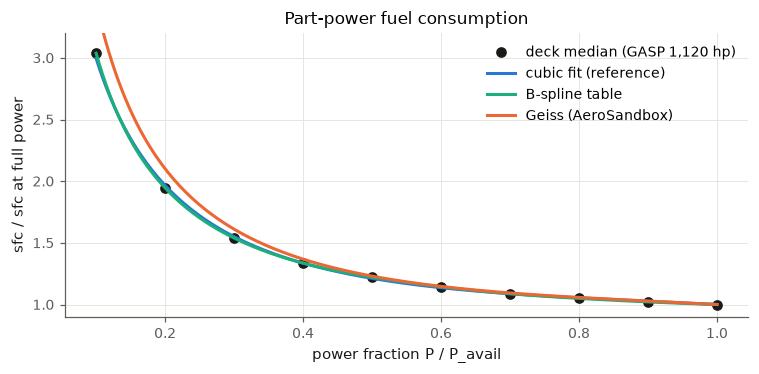

In [7]:
from aircraft_closure.powertrain.decks import fit_cubic_part_power
coefficients = fit_cubic_part_power(deck_1120hp_power_fraction, deck_1120hp_sfc_ratio)
print("refit:", onp.round(coefficients, 6), "\nin code:", onp.round(deck_1120hp_part_power_model().coefficients, 6))
check("the cubic in the code is the least-squares fit to the deck median",
      onp.allclose(coefficients, deck_1120hp_part_power_model().coefficients, atol=1e-9))

t = onp.linspace(0.1, 1.0, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(deck_1120hp_power_fraction, deck_1120hp_sfc_ratio, "o", color=ink, label="deck median (GASP 1,120 hp)")
for model, label, color in ((deck_1120hp_part_power_model(), "cubic fit (reference)", blue),
                            (TabulatedPartPowerModel(deck_1120hp_power_fraction, deck_1120hp_sfc_ratio), "B-spline table", aqua),
                            (GeissPartPowerModel(), "Geiss (AeroSandbox)", orange)):
    ax.plot(t, 1 / onp.array(model.efficiency_ratio(t)).ravel(), color=color, lw=2, label=label)
ax.set(xlabel="power fraction P / P_avail", ylabel="sfc / sfc at full power", ylim=(0.9, 3.2),
       title="Part-power fuel consumption")
ax.legend(); plt.tight_layout(); plt.show()

Why a cubic and not the B-spline? The table's steep low-power end made IPOPT stall for 3,000 iterations in the coupled problem
(plan 014). The cubic is within 1.1 % of the table from 20 % to 100 % power, where the engines actually run, and is smooth and
cheap everywhere.

Fuel flow at a few points, for one engine (with the class default full-power efficiency of 0.30; the Halo uses the regression value of section 6):

In [8]:
sea_level = asb.Atmosphere(0.0)
for power_hp in (300, 600, 900, 1120):
    r = engine.evaluate(power_hp * u.hp, sea_level)
    print(f"{power_hp:5d} hp: fuel {r.fuel_flow_kg_s * 3600:6.1f} kg/h, sfc {r.fuel_flow_kg_s * 3600 / (power_hp * u.hp / 1e3):.3f} kg/kWh, "
          f"efficiency {engine.thermal_efficiency_at(power_hp * u.hp, sea_level):.3f}")

  300 hp: fuel  103.2 kg/h, sfc 0.461 kg/kWh, efficiency 0.182
  600 hp: fuel  147.4 kg/h, sfc 0.330 kg/kWh, efficiency 0.254
  900 hp: fuel  197.2 kg/h, sfc 0.294 kg/kWh, efficiency 0.285
 1120 hp: fuel  233.1 kg/h, sfc 0.279 kg/kWh, efficiency 0.300


## 6. Engine mass and efficiency from a regression, inverted with an equality

AeroSandbox has regressions of turboshaft power and thermal efficiency against engine mass (`power_turboshaft(mass)`,
`thermal_efficiency_turboshaft(mass)`). The Halo knows the *power* (1,120 hp) and needs the *mass*. Rather than inverting the
regression with a root finder (a hidden solve), the driver makes the bare engine mass a design variable and adds the equality
`power_turboshaft(mass) == power` to the one big problem. The result reports the residual
(`turboshaft_mass_power_residual`). The same pattern, alone:

In [9]:
from aerosandbox.library.power_turboshaft import power_turboshaft, thermal_efficiency_turboshaft
opti = asb.Opti()
mass_engine_kg = opti.variable(init_guess=150.0, scale=100.0, lower_bound=10.0)
opti.subject_to(power_turboshaft(mass_engine_kg) / (1120 * u.hp) == 1)
solution = opti.solve(verbose=False)
m = solution.value(mass_engine_kg)
print(f"1,120 hp -> bare engine mass {m:.1f} kg ({lb(m):.0f} lb), regression efficiency {thermal_efficiency_turboshaft(m):.3f}")
check("the regression evaluated at the solved mass gives back 1,120 hp", abs(power_turboshaft(m) / u.hp - 1120) < 1e-3)

1,120 hp -> bare engine mass 184.2 kg (406 lb), regression efficiency 0.266
PASS  the regression evaluated at the solved mass gives back 1,120 hp


In the Halo the turboshaft component then gets `mass_kg = factor × bare mass` (the XV-15 power-plant calibration factor) and
`thermal_efficiency = thermal_efficiency_turboshaft(bare mass)`, both expressions of that variable.

In [10]:
import examples.halo_sizing as hs
source = inspect.getsource(hs.build_halo_aircraft)
start = source.find("    turboshaft = SimpleTurboshaft(")
print(source[start:start + 500])

    turboshaft = SimpleTurboshaft(power_rated_W=d.power_rated_turboshaft_W,
                                  mass_kg=factors.powerplant * d.mass_turboshaft_bare_kg,
                                  thermal_efficiency=thermal_efficiency_turboshaft(d.mass_turboshaft_bare_kg),
                                  lapse_exponent=lapse_exponent, part_power_model=a.part_power_model,
                                  lapse_model=xv15_lapse_model(lapse_exponent) if a.temperature_lapse else None)
    elec


## Limits and next steps

**What it can't do**

- **Relaxed gear stages** are non-integer (the sized gearbox happens to be one stage); no clutch or combiner mass for the lanes beyond the AFDD drive weight.
- **Turboshaft:** one lapse exponent, no ram recovery or Mach effect, no contingency rating, a fixed output speed, no tailpipe thrust, no exhaust heat. The
  deck's own altitude columns were non-monotonic and are not used; only its normalized part-power curve is.

**What's next:** supplier gearbox data; integer stage counts by enumeration; the installed engine deck with its real altitude and Mach behaviour once its
correction convention is known (`docs/decisions/014`).

## Summary

- Gearbox loss comes off the torque; the flight point runs the chain backwards from the rotor.
- `GearStageModel` makes stage count, efficiency and mass factor smooth functions of the ratio (staircase or relaxed).
- Drive mass follows the AFDD equations (output torque matters), calibrated on the XV-15, times a stage mass factor.
- The turboshaft's power available lapses with density and temperature (both fitted to the XV-15); it is a margin, not a clip.
- Part-power fuel flow comes from a cubic fitted to an engine deck, because splines through steep data stall IPOPT.
- Regressions are inverted by an equality inside the problem, never by a root finder.

## Check yourself

<details><summary>1. Why is the turboshaft limit evaluated with the point's atmosphere but the motor's is not?</summary>

A turboshaft's power available depends on inlet density and temperature; an electric machine's torque, speed and power limits do not (in this model). `operating_margins` passes the point's atmosphere and only the turboshaft (and cable partial discharge) use it.
</details>

<details><summary>2. A colleague proposes replacing the cubic part-power model by the B-spline table "for accuracy". What do you check first?</summary>

Where the engines operate in the sized design (power fractions in each segment) and the cubic's error there (about 1 %), and whether the coupled problem still converges with the spline. Plan 014 records it did not.
</details>

In [11]:
check_summary()

5 of 5 checks passed
